In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
!python --version

Python 3.12.13


# Tensor - este un fel de array

In [4]:
numere = np.array([1, 2, 3, 4])
numere

array([1, 2, 3, 4])

In [5]:
tf.constant(numere)

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>

In [6]:
numere.shape

(4,)

In [7]:
tf.zeros(shape=(2, 3))

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

In [8]:
tf.ones(shape=(10,))

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)>

In [10]:
my_tensor = tf.fill(dims=(3, 3), value=16)
my_tensor

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[16, 16, 16],
       [16, 16, 16],
       [16, 16, 16]], dtype=int32)>

In [11]:
type(my_tensor)

tensorflow.python.framework.ops.EagerTensor

In [13]:
my_numpy_value = my_tensor.numpy()
my_numpy_value, type(my_numpy_value)

(array([[16, 16, 16],
        [16, 16, 16],
        [16, 16, 16]], dtype=int32),
 numpy.ndarray)

In [16]:
my_tensor_var = tf.Variable(my_numpy_value)
my_tensor_var

<tf.Variable 'Variable:0' shape=(3, 3) dtype=int32, numpy=
array([[16, 16, 16],
       [16, 16, 16],
       [16, 16, 16]], dtype=int32)>

In [19]:
my_tensor_var

<tf.Variable 'Variable:0' shape=(3, 3) dtype=int32, numpy=
array([[16, 16, 16],
       [16, 16, 16],
       [16, 16, 16]], dtype=int32)>

# Cum construim un model in Tensorflow

In [20]:
from sklearn.linear_model import LinearRegression

LinearRegression()

LinearRegression()

In [21]:
tf.keras

<module 'keras._tf_keras.keras' from '/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/__init__.py'>

# Versiunea 1 - adaugarea layer cu add

In [22]:
model_generic = tf.keras.models.Sequential()
model_generic

<Sequential name=sequential, built=False>

In [23]:
input_layer = tf.keras.layers.InputLayer(shape=(8,8))

In [24]:
model_generic.add(input_layer)

In [26]:
model_generic.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Versiunea 2 - adaugarea layerelor ca o lista

In [27]:
model_generic = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer(shape=(8,8))

    ]
)
model_generic.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Adaugarea layerelor dense

In [28]:
model_generic = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer(shape=(8,8)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(6, activation="relu"),
        tf.keras.layers.Dense(3, activation="relu"),

    ]
)
model_generic.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8, 8)           │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8, 6)           │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8, 3)           │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 147 (588.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
model_generic = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer(shape=(2, )),
        tf.keras.layers.Dense(4, activation="relu"),
        tf.keras.layers.Dense(2, activation="relu")

    ]
)
model_generic.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22 (88.00 B)

 Trainable params: 22 (88.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
mnist = tf.keras.datasets.mnist


In [33]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
x_train.shape

(60000, 28, 28)

In [36]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

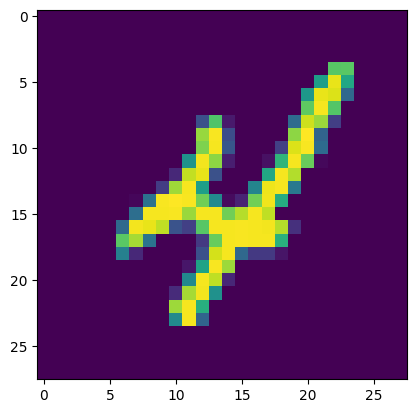

In [37]:
plt.imshow(x_train[9])

In [39]:
x_train = x_train / 255

In [40]:
x_test = x_test / 255

In [41]:
x_train.shape

(60000, 28, 28)

In [48]:
model_mnist = tf.keras.models.Sequential(
    [
        ## INPUT nenogociabil
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),


        ## OUTPUT este nenegociabil
        tf.keras.layers.Dense(10, activation="softmax")

    ]
)
model_mnist.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
784 * 64 + 64

50240

In [49]:
model_mnist.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [50]:
model_mnist.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9161 - loss: 0.2919
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9612 - loss: 0.1299
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9716 - loss: 0.0947
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9771 - loss: 0.0749
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9805 - loss: 0.0614
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9843 - loss: 0.0521
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9864 - loss: 0.0440
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9872 - loss: 0.0405
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9897 - loss: 0.0331
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9901 - loss: 0.0302


In [51]:
model_mnist.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9734 - loss: 0.0954


[0.0953950509428978, 0.9733999967575073]

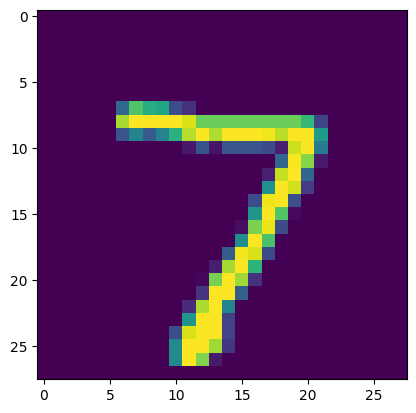

In [53]:
plt.imshow(x_test[0])

In [56]:
predictions = model_mnist.predict(np.array([x_test[0]]))
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step


array([[1.9998926e-11, 4.4922746e-10, 3.1008568e-08, 6.5034260e-07,
        1.6578664e-13, 1.7565790e-09, 1.3338033e-17, 9.9999917e-01,
        3.7560465e-08, 1.1678875e-07]], dtype=float32)

In [57]:
predictions.max()

np.float32(0.99999917)

In [58]:
predictions.argmax()

np.int64(7)

In [59]:
x_test.shape

(10000, 28, 28)

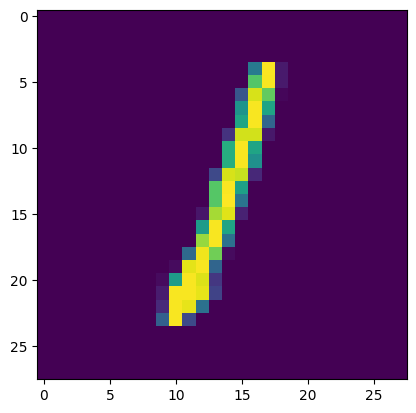

In [60]:
plt.imshow(x_test[7000])

In [61]:
y_test[7000]

np.uint8(1)

In [64]:
predictions = model_mnist.predict(np.array([x_test[7000]]))
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[2.5012039e-08, 9.9985659e-01, 1.1586923e-05, 1.2843105e-09,
        1.6755913e-06, 1.2535479e-07, 8.4284657e-05, 6.1863557e-06,
        3.9540584e-05, 1.7952784e-09]], dtype=float32)

In [65]:
predictions.max(), predictions.argmax()

(np.float32(0.9998566), np.int64(1))

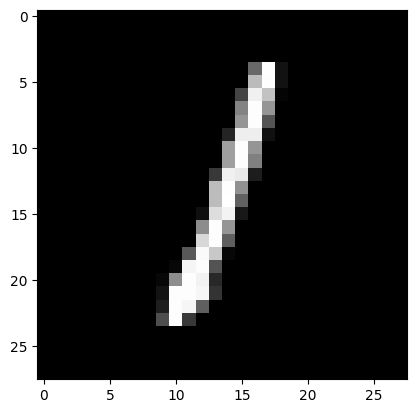

In [66]:
plt.imshow(x_test[7000], cmap="gray")

In [67]:
from PIL import Image

In [82]:
imagine_citita = Image.open("/content/SASE.png")

In [83]:
image_conv = imagine_citita.convert("L")
type(image_conv)

PIL.Image.Image

In [84]:
img = np.array(image_conv) / 255
img.shape

(28, 28)

In [78]:
x_test[0].shape

(28, 28)

In [79]:
img.shape

(28, 28)

In [85]:
model_mnist.predict(np.array([img])).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


np.int64(6)